### ⚙️ Exercício 5: Teleporte Quântico

Implemente o *protocolo de teleporte quântico* usando o Ket. Sua implementação deve seguir os passos descritos abaixo:

O teleporte quântico é um protocolo que permite a *transferência de informações quânticas* de um qubit para outro sem que o qubit original seja fisicamente movido. Isso é possível usando um canal quântico (qubits emaranhados) e dois canais clássicos para comunicação.

O processo envolve duas partes: *Alice*, que possui o qubit a ser teleportado, e *Bob*, que o receberá. Para o teleporte quântico, um *estado de Bell* é inicialmente compartilhado entre Alice e Bob. Um dos estados de Bell mais comuns é:

$$\left| \Phi^+ \right> = \frac{1}{\sqrt{2}} \left( \left|00\right> + \left|11\right> \right)$$

Nesse estado, os qubits de Alice e Bob estão *emaranhados*, permitindo a transferência da informação de Alice para Bob. O protocolo inclui medições e a transmissão de resultados clássicos, o que permite a Bob recuperar o estado original de Alice.

<img src="https://upload.wikimedia.org/wikipedia/commons/d/dc/Quantum_teleportation_circuit.svg" alt="teleporte" width="500"/>

**Sua implementação deve incluir os seguintes passos:**

1.  **Preparação do Estado de Bell**: Alocar os qubits necessários e preparar o estado de Bell compartilhado entre Alice e Bob.
2.  **Aplicação de Portas Quânticas**: Realizar as operações quânticas necessárias para entrelaçar o qubit a ser teleportado com o estado de Bell.
3.  **Medição**: Medir os qubits de Alice.
4.  **Correção**: Enviar os resultados das medições para Bob e aplicar as correções necessárias em seu qubit para recuperar o estado original.

Vamos Implementar o código em Qiskit!


In [ ]:
### Primeira etapa: Instalção do Qiskit
!pip install -q qiskit qiskit-aer matplotlib
!pip install -q pylatexenc
%matplotlib inline

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.result import marginal_counts

**1° Passo**: Primeiro começamos com a organização do código, lembramos que no qiskit precisamos definir algumas constantes, como a,b e c, pois é importante para a origanização do código, não existe física associada neste passo.
Na simulação o computador só entende qubits como algo do tipo q[0], q[1],q[2].

In [ ]:
a=1  #(auxiliar Alice)
b=2  # (auxiliar da Bob)
c=0  #(estado que queremos mandar)

**2° Passo**: Precisamos criar os resgitradores dos bits classicos e quânticos.


In [ ]:
q = QuantumRegister(3,"q") # Aqui vamos criar 3 qubits
m = ClassicalRegister(3, "m") # Criamos 3 bits clássicos para guardar os resultados de medidas.
qc = QuantumCircuit(q,m) # Criamos o circuito juntando os dois

**3° Passo:** Prepara o estado |+> no qubit c. Lembrando que esse passo é importante porque quando atuamos a porta H p efeito dela é colocar o qubit em superposição, ou seja, $$
H \lvert 0 \rangle \rightarrow \lvert + \rangle = \frac{\lvert 0 \rangle + \lvert 1 \rangle}{\sqrt{2}}
$$




In [ ]:
qc.h(q[c])

**4° Passo:** Parte que a Alice precisa criar o emaranhamento entre a e b, ou seja, entre ela e o Bob. Isso acontece, porque suponhamos que Alice quer mandar uma mesg para o Bob, então eles combinam um estado emaranhado, que eles criam juntos, e Bob futuramente usa esse estado para **reconstruiur** a informção quântica teleportada.

In [ ]:
qc.h(q[a])
qc.cx(q[a],q[b])

**5° Passo**: Agora criamos o circuito quântico que está representado na imagem acima composto no bloco da CNOT seguido da Hadamard.

In [ ]:
qc.cx(q[c], q[a])
qc.h(q[c])

**6° Passo**: Parte das medidas. Reconstruimos a parte da medida exatamente da mesma maneira representada na imagem acima. Como os qubits (a,c) estão inicialmente com a Alice é necessário medir o qubit c (porque contém o estado que queremos teletransporta) e o qubit a (porque contém a metade do par emaranhado). Medir o qubit, significa que todas as informaçãoes serão perdidas, ou seja, destrói o estado quântico, lembrando que esse estado não pode ser copiado (teorema da não clonagem) a alice destrói para que Bob consiga resconstruiur depois.

In [ ]:
qc.measure(q[c], m[0]) # aqui Alice mede o qubit c e salva em m[0].
qc.measure(q[a], m[1]) # Alice mede em a e salva em m[1].

**7º Passo**: Passo da reconstrução. Nesta etapa do processo aplicamos correções para que Bob consiga reconstruiur o estado que foi teletransportado, ou seja, o estado |+> que definimos anteriormente.

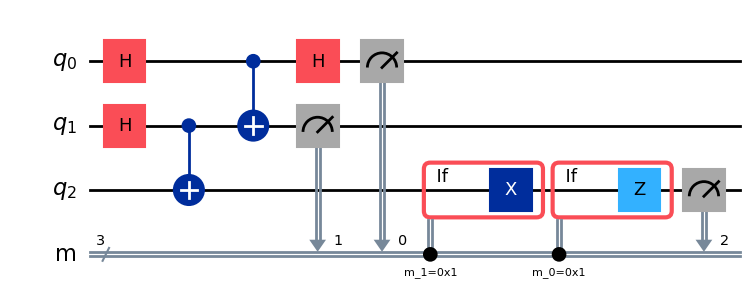

In [ ]:
with qc.if_test((m[1],1)): ##  with qc.if_test((m[bit classico],valor) Se o bit clássico tiver esse valor aplique a porta x
     qc.x(q[b])
with qc.if_test((m[0],1)):
     qc.z(q[b])
# A correção significa que se estiver a porta x corrige, ou seja, troca de 0->1
# A porta z troca de sinal de |1>.

# medida final do qubit do Bob para checar o resultado
#qc.h(q[b])   # 👈 TESTE RÁPIDO
qc.measure(q[b], m[2])
qc.draw("mpl")



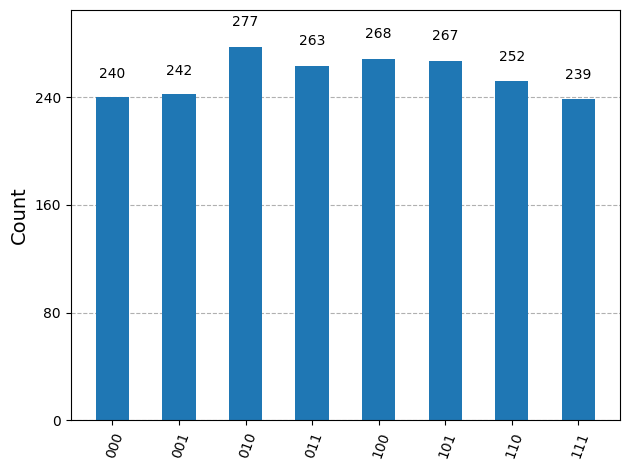

In [ ]:
# --- simulação e histograma ---
# O histograma mmostra todas as medidas aleatórias  m[2] m[1] m[0], onde podemos verificar que as medidas ficam uniformes, pois alice tem 50% de medir  0 ou 1 e m[0] ou m[1].

sim = AerSimulator()
tqc = transpile(qc, sim)

result = sim.run(tqc, shots=2048).result()
counts = result.get_counts()

counts
plot_histogram(counts)




Histograma apenas do Bob


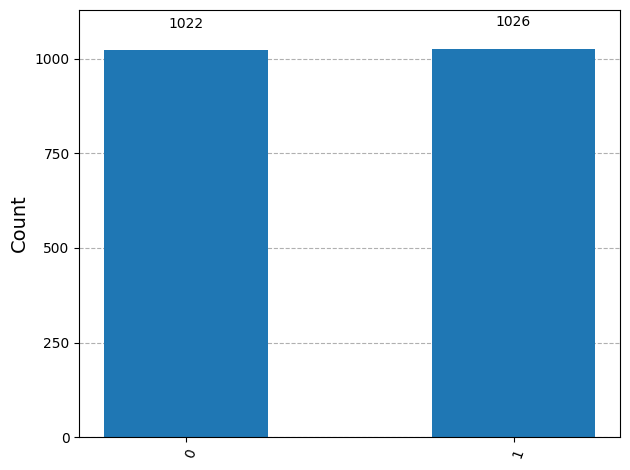

In [ ]:
print("Histograma apenas do Bob")
# Maneira de filtrar como pegar o resultado apenas de Bob.

counts_bob = marginal_counts(counts, [2])
plot_histogram(counts_bob)